# **Simple Convolutional Autoencoder**

169001437/169001437 [==============================] - 6s 0us/step
Epoch 1/150
313/313 [==============================] - 10s 13ms/step - loss: 0.0176 - val_loss: 0.0090
Epoch 2/150
313/313 [==============================] - 3s 8ms/step - loss: 0.0076 - val_loss: 0.0068
Epoch 3/150
313/313 [==============================] - 3s 10ms/step - loss: 0.0064 - val_loss: 0.0062
Epoch 4/150
313/313 [==============================] - 3s 10ms/step - loss: 0.0059 - val_loss: 0.0056
Epoch 5/150
313/313 [==============================] - 3s 8ms/step - loss: 0.0056 - val_loss: 0.0054
Epoch 6/150
313/313 [==============================] - 3s 8ms/step - loss: 0.0053 - val_loss: 0.0051
Epoch 7/150
313/313 [==============================] - 3s 8ms/step - loss: 0.0051 - val_loss: 0.0049
Epoch 8/150
313/313 [==============================] - 3s 10ms/step - loss: 0.0049 - val_loss: 0.0047
Epoch 9/150
313/313 [==============================] - 3s 10ms/step - loss: 0.0047 - val_loss: 0.0046
Epoch 10/150
313/3

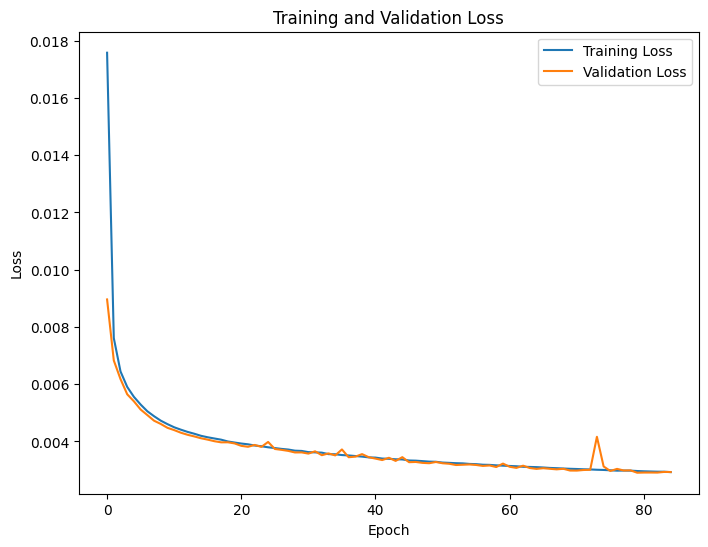

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


313/313 [==============================] - 1s 2ms/step
Metrics for Test Dataset:
Test MSE: 0.0030
Test MAE: 0.0382
Test PSNR: 25.25
Test SSIM: 0.97


In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.callbacks import EarlyStopping
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
from sklearn.metrics import mean_squared_error

# Define the autoencoder model
model = Sequential()

# Encoder
model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))
model.add(MaxPooling2D((2, 2), padding='same'))
model.add(Conv2D(16, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2), padding='same'))

# Decoder
model.add(Conv2D(16, (3, 3), activation='relu', padding='same'))
model.add(UpSampling2D((2, 2)))
model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
model.add(UpSampling2D((2, 2)))
model.add(Conv2D(3, (3, 3), activation='sigmoid', padding='same'))

# Compile the model
model.compile(optimizer='adam', loss='mse')

# Split the train dataset into train and validation
(x_train, _), (x_test, _) = tf.keras.datasets.cifar100.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

val_size = 0.2
val_index = int(len(x_train) * (1 - val_size))
x_val = x_train[val_index:]
x_train = x_train[:val_index]

# Train the model
early_stopping = EarlyStopping(monitor='val_loss', patience=5)

history = model.fit(x_train, x_train,
                   epochs=150,
                   batch_size=128,
                   shuffle=True,
                   validation_data=(x_val, x_val),
                   callbacks=[early_stopping])

# Plot the training and validation loss
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

# Save the model
model.save('/content/drive/MyDrive/Colab Notebooks/DLSIP_project/autoencoder_model.h5')

# Compute metrics for test dataset
encoder = Sequential()
for layer in model.layers[:4]:
    encoder.add(layer)

decoder = Sequential()
for layer in model.layers[4:]:
    decoder.add(layer)

test_reconstructed = decoder.predict(encoder.predict(x_test))
test_reconstructed = np.squeeze(test_reconstructed)

test_mse = mean_squared_error(x_test.reshape(x_test.shape[0], -1), test_reconstructed.reshape(test_reconstructed.shape[0], -1))
test_mae = np.mean(np.abs(x_test.reshape(x_test.shape[0], -1) - test_reconstructed.reshape(test_reconstructed.shape[0], -1)))
test_psnr = peak_signal_noise_ratio(x_test, test_reconstructed, data_range=1.0)
test_ssim = structural_similarity(x_test, test_reconstructed, channel_axis=-1, data_range=1.0)

print("Metrics for Test Dataset:")
print(f"Test MSE: {test_mse:.4f}")
print(f"Test MAE: {test_mae:.4f}")
print(f"Test PSNR: {test_psnr:.2f}")
print(f"Test SSIM: {test_ssim:.2f}")

## **Sender**

In [51]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.callbacks import EarlyStopping
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
from sklearn.metrics import mean_squared_error

# Load and preprocess the input image
image_path = '/content/drive/MyDrive/Colab Notebooks/DLSIP_project/Screenshot 2023-07-31 095636.jpg'
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
original_image = image.copy()
img = cv2.resize(image, (32, 32))
img = np.expand_dims(img, axis=0) / 255.0

# Load the saved model
loaded_model = load_model('/content/drive/MyDrive/Colab Notebooks/DLSIP_project/autoencoder_model.h5')

# Extract the semantic features
encoder = Sequential()
for layer in loaded_model.layers[:4]:
    encoder.add(layer)

semantic_features = encoder.predict(img)

print(semantic_features)
print(semantic_features.size)

1/1 [==============================] - 0s 43ms/step
[[[[0.49368167 0.53400934 0.20330451 ... 0.3788403  0.19090095
    0.25165343]
   [0.40996063 0.5182886  0.23798755 ... 0.2946749  0.22976819
    0.29325113]
   [0.50802785 0.4860414  0.29794395 ... 0.39750814 0.17744067
    0.18194938]
   ...
   [0.5556127  0.5790058  0.30878758 ... 0.4162421  0.22120476
    0.18554772]
   [0.5663037  0.3693217  0.26517212 ... 0.42089707 0.20307243
    0.23269494]
   [0.7435873  0.5130228  0.20860605 ... 0.5872009  0.2757431
    0.36558264]]

  [[0.3949879  0.51980907 0.2432459  ... 0.3565824  0.24729583
    0.2690157 ]
   [0.3690518  0.46594167 0.29412097 ... 0.3243318  0.22963446
    0.28869793]
   [0.4756238  0.5432677  0.35982445 ... 0.37007406 0.22038949
    0.1642685 ]
   ...
   [0.30610085 0.55157614 0.40373966 ... 0.29067084 0.18839565
    0.21791619]
   [0.52849996 0.523844   0.3356311  ... 0.4612887  0.17217189
    0.1802726 ]
   [0.6812815  0.5157567  0.26432097 ... 0.57379556 0.24995574
 

## **Reciever**

1/1 [==============================] - 0s 78ms/step

Metrics for Input Image: (between resized and reconstructed image)
Input MSE: 0.0074
Input MAE: 0.0548
Input PSNR: 21.28
Input SSIM: 0.64


<ipython-input-52-bf28f3616523>:31: FutureWarning: `multichannel` is a deprecated argument name for `structural_similarity`. It will be removed in version 1.0. Please use `channel_axis` instead.
  input_ssim = structural_similarity(original_image, resized_reconstructed_image, multichannel=True, data_range=255)



Metrics for Input Image (between original image and resized reconstructed image):
Input MSE: 68.5119
Input MAE: 142.7451
Input PSNR: 20.39
Input SSIM: 0.8063


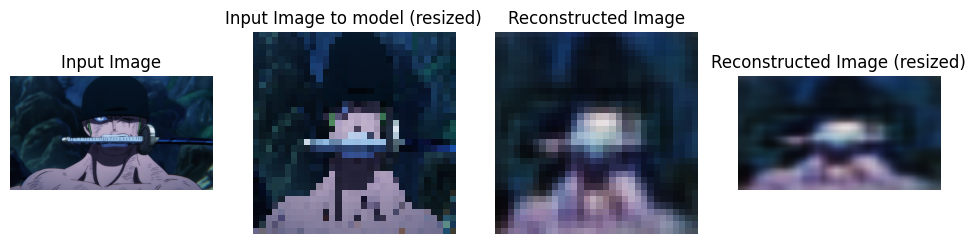

In [52]:
decoder = Sequential()
for layer in loaded_model.layers[4:]:
    decoder.add(layer)

# Reconstruct the image using the semantic features
reconstructed_image = decoder.predict(semantic_features)

# Compute metrics for input image
reconstructed_image_flat = np.squeeze(reconstructed_image).reshape(-1, 3)
img_flat = img.reshape(-1, 3)

input_mse = mean_squared_error(img_flat, reconstructed_image_flat)
input_mae = np.mean(np.abs(img_flat - reconstructed_image_flat))
input_psnr = peak_signal_noise_ratio(img_flat, reconstructed_image_flat, data_range=1.0)
input_ssim = structural_similarity(img_flat, reconstructed_image_flat, channel_axis=-1, data_range=1.0)

print("\nMetrics for Input Image: (between resized and reconstructed image)")
print(f"Input MSE: {input_mse:.4f}")
print(f"Input MAE: {input_mae:.4f}")
print(f"Input PSNR: {input_psnr:.2f}")
print(f"Input SSIM: {input_ssim:.2f}")

# Resize the reconstructed image back to the original size
resized_reconstructed_image = cv2.resize(np.squeeze(reconstructed_image) * 255, (original_image.shape[1], original_image.shape[0]))
resized_reconstructed_image = resized_reconstructed_image.astype('uint8')

# Compute metrics for input image compared to original image
input_mse = mean_squared_error(original_image.reshape(-1, 3), resized_reconstructed_image.reshape(-1, 3))
input_mae = np.mean(np.abs(original_image.reshape(-1, 3) - resized_reconstructed_image.reshape(-1, 3)))
input_psnr = peak_signal_noise_ratio(original_image, resized_reconstructed_image, data_range=255)
input_ssim = structural_similarity(original_image, resized_reconstructed_image, multichannel=True, data_range=255)

print("\nMetrics for Input Image (between original image and resized reconstructed image):")
print(f"Input MSE: {input_mse:.4f}")
print(f"Input MAE: {input_mae:.4f}")
print(f"Input PSNR: {input_psnr:.2f}")
print(f"Input SSIM: {input_ssim:.4f}")

# Save the original image
cv2.imwrite('/content/drive/MyDrive/Colab Notebooks/DLSIP_project/SRGAN/original_image1_CAE.png', cv2.cvtColor(original_image, cv2.COLOR_RGB2BGR))

# Save the resized reconstructed image
cv2.imwrite('/content/drive/MyDrive/Colab Notebooks/DLSIP_project/SRGAN/resized_reconstructed_image1_CAE.png', cv2.cvtColor(resized_reconstructed_image, cv2.COLOR_RGB2BGR))

# Plot the input image, resized input image, and reconstructed image
plt.figure(figsize=(12, 4))
plt.subplot(1, 4, 1)
plt.imshow(original_image)
plt.axis('off')
plt.title('Input Image')

plt.subplot(1, 4, 2)
plt.imshow(img[0])
plt.axis('off')
plt.title('Input Image to model (resized)')

plt.subplot(1, 4, 3)
plt.imshow(np.squeeze(reconstructed_image))
plt.axis('off')
plt.title('Reconstructed Image')

plt.subplot(1, 4, 4)
plt.imshow(resized_reconstructed_image)
plt.axis('off')
plt.title('Reconstructed Image (resized)')

plt.show()

# **Sender**

In [53]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.callbacks import EarlyStopping
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
from sklearn.metrics import mean_squared_error

# Load and preprocess the input image
image_path = '/content/drive/MyDrive/Colab Notebooks/DLSIP_project/Screenshot 2023-08-14 180929.png'
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
original_image = image.copy()
img = cv2.resize(image, (32, 32))
img = np.expand_dims(img, axis=0) / 255.0

# Load the saved model
loaded_model = load_model('/content/drive/MyDrive/Colab Notebooks/DLSIP_project/autoencoder_model.h5')

# Extract the semantic features
encoder = Sequential()
for layer in loaded_model.layers[:4]:
    encoder.add(layer)

semantic_features = encoder.predict(img)

print(semantic_features)
print(semantic_features.size)

1/1 [==============================] - 0s 48ms/step
[[[[1.02597690e+00 2.76092470e-01 0.00000000e+00 ... 7.27420449e-01
    1.74353987e-01 2.05488533e-01]
   [1.08342719e+00 1.59726053e-01 0.00000000e+00 ... 8.12834859e-01
    2.74702430e-01 1.55646518e-01]
   [8.75290692e-01 2.28589743e-01 0.00000000e+00 ... 6.60712957e-01
    3.45209777e-01 3.28260362e-01]
   ...
   [1.05424833e+00 1.26525939e-01 0.00000000e+00 ... 7.71013618e-01
    2.70941854e-01 2.04643339e-01]
   [8.34241569e-01 1.97288245e-01 6.31034374e-04 ... 6.33958936e-01
    2.78313696e-01 2.03216314e-01]
   [7.87675202e-01 4.44687724e-01 1.92027628e-01 ... 6.25456333e-01
    2.04545945e-01 2.97640026e-01]]

  [[9.90675390e-01 2.20969409e-01 3.12061682e-02 ... 8.19476724e-01
    1.82269722e-01 2.03709796e-01]
   [1.09177256e+00 2.59242147e-01 0.00000000e+00 ... 7.78747797e-01
    3.37017119e-01 2.57871568e-01]
   [7.22012639e-01 2.83983976e-01 0.00000000e+00 ... 6.81053042e-01
    3.07832271e-01 3.61250907e-01]
   ...
   [1

## **Reciever**

1/1 [==============================] - 0s 75ms/step

Metrics for Input Image: (between resized and reconstructed image)
Input MSE: 0.0062
Input MAE: 0.0535
Input PSNR: 22.06
Input SSIM: 0.72


<ipython-input-54-7da3361ff046>:31: FutureWarning: `multichannel` is a deprecated argument name for `structural_similarity`. It will be removed in version 1.0. Please use `channel_axis` instead.
  input_ssim = structural_similarity(original_image, resized_reconstructed_image, multichannel=True, data_range=255)



Metrics for Input Image (between original image and resized reconstructed image):
Input MSE: 73.8544
Input MAE: 127.6336
Input PSNR: 20.95
Input SSIM: 0.6682


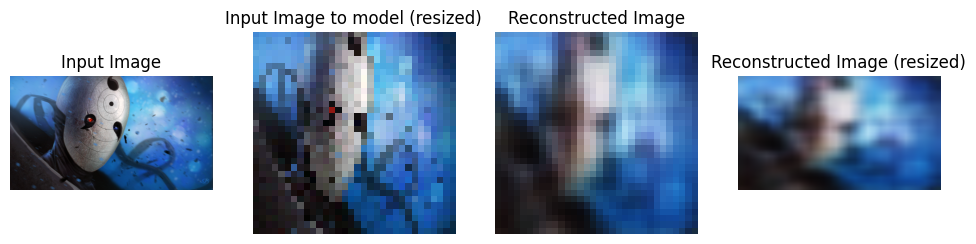

In [54]:
decoder = Sequential()
for layer in loaded_model.layers[4:]:
    decoder.add(layer)

# Reconstruct the image using the semantic features
reconstructed_image = decoder.predict(semantic_features)

# Compute metrics for input image
reconstructed_image_flat = np.squeeze(reconstructed_image).reshape(-1, 3)
img_flat = img.reshape(-1, 3)

input_mse = mean_squared_error(img_flat, reconstructed_image_flat)
input_mae = np.mean(np.abs(img_flat - reconstructed_image_flat))
input_psnr = peak_signal_noise_ratio(img_flat, reconstructed_image_flat, data_range=1.0)
input_ssim = structural_similarity(img_flat, reconstructed_image_flat, channel_axis=-1, data_range=1.0)

print("\nMetrics for Input Image: (between resized and reconstructed image)")
print(f"Input MSE: {input_mse:.4f}")
print(f"Input MAE: {input_mae:.4f}")
print(f"Input PSNR: {input_psnr:.2f}")
print(f"Input SSIM: {input_ssim:.2f}")

# Resize the reconstructed image back to the original size
resized_reconstructed_image = cv2.resize(np.squeeze(reconstructed_image) * 255, (original_image.shape[1], original_image.shape[0]))
resized_reconstructed_image = resized_reconstructed_image.astype('uint8')

# Compute metrics for input image compared to original image
input_mse = mean_squared_error(original_image.reshape(-1, 3), resized_reconstructed_image.reshape(-1, 3))
input_mae = np.mean(np.abs(original_image.reshape(-1, 3) - resized_reconstructed_image.reshape(-1, 3)))
input_psnr = peak_signal_noise_ratio(original_image, resized_reconstructed_image, data_range=255)
input_ssim = structural_similarity(original_image, resized_reconstructed_image, multichannel=True, data_range=255)

print("\nMetrics for Input Image (between original image and resized reconstructed image):")
print(f"Input MSE: {input_mse:.4f}")
print(f"Input MAE: {input_mae:.4f}")
print(f"Input PSNR: {input_psnr:.2f}")
print(f"Input SSIM: {input_ssim:.4f}")

# Save the original image
cv2.imwrite('/content/drive/MyDrive/Colab Notebooks/DLSIP_project/SRGAN/original_image2_CAE.png', cv2.cvtColor(original_image, cv2.COLOR_RGB2BGR))

# Save the resized reconstructed image
cv2.imwrite('/content/drive/MyDrive/Colab Notebooks/DLSIP_project/SRGAN/resized_reconstructed_image2_CAE.png', cv2.cvtColor(resized_reconstructed_image, cv2.COLOR_RGB2BGR))

# Plot the input image, resized input image, and reconstructed image
plt.figure(figsize=(12, 4))
plt.subplot(1, 4, 1)
plt.imshow(original_image)
plt.axis('off')
plt.title('Input Image')

plt.subplot(1, 4, 2)
plt.imshow(img[0])
plt.axis('off')
plt.title('Input Image to model (resized)')

plt.subplot(1, 4, 3)
plt.imshow(np.squeeze(reconstructed_image))
plt.axis('off')
plt.title('Reconstructed Image')

plt.subplot(1, 4, 4)
plt.imshow(resized_reconstructed_image)
plt.axis('off')
plt.title('Reconstructed Image (resized)')

plt.show()

# **Sender**

In [55]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.callbacks import EarlyStopping
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
from sklearn.metrics import mean_squared_error

# Load and preprocess the input image
image_path = '/content/drive/MyDrive/Colab Notebooks/DLSIP_project/Screenshot 2023-12-12 201012.png'
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
original_image = image.copy()
img = cv2.resize(image, (32, 32))
img = np.expand_dims(img, axis=0) / 255.0

# Load the saved model
loaded_model = load_model('/content/drive/MyDrive/Colab Notebooks/DLSIP_project/autoencoder_model.h5')

# Extract the semantic features
encoder = Sequential()
for layer in loaded_model.layers[:4]:
    encoder.add(layer)

semantic_features = encoder.predict(img)

print(semantic_features)
print(semantic_features.size)

1/1 [==============================] - 0s 52ms/step
[[[[0.3533484  0.8242327  0.05950409 ... 0.5206481  0.30707765
    0.5287344 ]
   [0.40360847 1.044755   0.         ... 0.67186785 0.5144998
    0.6781085 ]
   [0.23260218 0.9238094  0.         ... 0.408655   0.5599373
    0.49603587]
   ...
   [0.12110808 0.8913654  0.         ... 0.27712858 0.36997446
    0.39714858]
   [0.06886642 0.7875018  0.13295878 ... 0.18079448 0.31201145
    0.3571162 ]
   [0.4581667  0.84866774 0.1314944  ... 0.44958085 0.28595653
    0.39081734]]

  [[0.46579695 0.87683284 0.         ... 0.63943493 0.33936152
    0.5753565 ]
   [0.42470288 1.0401419  0.         ... 0.6791358  0.5668979
    0.73456955]
   [0.2508726  0.8960382  0.         ... 0.44055647 0.521437
    0.5538682 ]
   ...
   [0.13001665 0.86856806 0.         ... 0.3041493  0.36559454
    0.4661386 ]
   [0.13943072 0.7871804  0.07123411 ... 0.2536343  0.31641513
    0.35607108]
   [0.45704374 0.86541224 0.07719771 ... 0.43617323 0.27777708
    0

## **Reciever**

1/1 [==============================] - 0s 77ms/step

Metrics for Input Image: (between resized and reconstructed image)
Input MSE: 0.0090
Input MAE: 0.0603
Input PSNR: 20.48
Input SSIM: 0.73


<ipython-input-56-9fe9c41dff13>:31: FutureWarning: `multichannel` is a deprecated argument name for `structural_similarity`. It will be removed in version 1.0. Please use `channel_axis` instead.
  input_ssim = structural_similarity(original_image, resized_reconstructed_image, multichannel=True, data_range=255)



Metrics for Input Image (between original image and resized reconstructed image):
Input MSE: 71.0782
Input MAE: 154.8171
Input PSNR: 19.18
Input SSIM: 0.7713


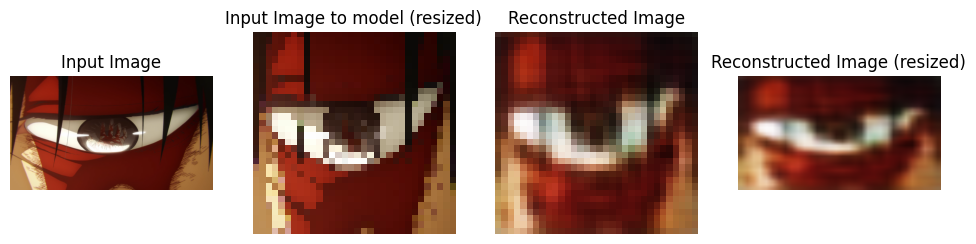

In [56]:
decoder = Sequential()
for layer in loaded_model.layers[4:]:
    decoder.add(layer)

# Reconstruct the image using the semantic features
reconstructed_image = decoder.predict(semantic_features)

# Compute metrics for input image
reconstructed_image_flat = np.squeeze(reconstructed_image).reshape(-1, 3)
img_flat = img.reshape(-1, 3)

input_mse = mean_squared_error(img_flat, reconstructed_image_flat)
input_mae = np.mean(np.abs(img_flat - reconstructed_image_flat))
input_psnr = peak_signal_noise_ratio(img_flat, reconstructed_image_flat, data_range=1.0)
input_ssim = structural_similarity(img_flat, reconstructed_image_flat, channel_axis=-1, data_range=1.0)

print("\nMetrics for Input Image: (between resized and reconstructed image)")
print(f"Input MSE: {input_mse:.4f}")
print(f"Input MAE: {input_mae:.4f}")
print(f"Input PSNR: {input_psnr:.2f}")
print(f"Input SSIM: {input_ssim:.2f}")

# Resize the reconstructed image back to the original size
resized_reconstructed_image = cv2.resize(np.squeeze(reconstructed_image) * 255, (original_image.shape[1], original_image.shape[0]))
resized_reconstructed_image = resized_reconstructed_image.astype('uint8')

# Compute metrics for input image compared to original image
input_mse = mean_squared_error(original_image.reshape(-1, 3), resized_reconstructed_image.reshape(-1, 3))
input_mae = np.mean(np.abs(original_image.reshape(-1, 3) - resized_reconstructed_image.reshape(-1, 3)))
input_psnr = peak_signal_noise_ratio(original_image, resized_reconstructed_image, data_range=255)
input_ssim = structural_similarity(original_image, resized_reconstructed_image, multichannel=True, data_range=255)

print("\nMetrics for Input Image (between original image and resized reconstructed image):")
print(f"Input MSE: {input_mse:.4f}")
print(f"Input MAE: {input_mae:.4f}")
print(f"Input PSNR: {input_psnr:.2f}")
print(f"Input SSIM: {input_ssim:.4f}")

# Save the original image
cv2.imwrite('/content/drive/MyDrive/Colab Notebooks/DLSIP_project/SRGAN/original_image3_CAE.png', cv2.cvtColor(original_image, cv2.COLOR_RGB2BGR))

# Save the resized reconstructed image
cv2.imwrite('/content/drive/MyDrive/Colab Notebooks/DLSIP_project/SRGAN/resized_reconstructed_image3_CAE.png', cv2.cvtColor(resized_reconstructed_image, cv2.COLOR_RGB2BGR))

# Plot the input image, resized input image, and reconstructed image
plt.figure(figsize=(12, 4))
plt.subplot(1, 4, 1)
plt.imshow(original_image)
plt.axis('off')
plt.title('Input Image')

plt.subplot(1, 4, 2)
plt.imshow(img[0])
plt.axis('off')
plt.title('Input Image to model (resized)')

plt.subplot(1, 4, 3)
plt.imshow(np.squeeze(reconstructed_image))
plt.axis('off')
plt.title('Reconstructed Image')

plt.subplot(1, 4, 4)
plt.imshow(resized_reconstructed_image)
plt.axis('off')
plt.title('Reconstructed Image (resized)')

plt.show()

# **Deeper Convolutional Neural Network**

Epoch 1/100
313/313 [==============================] - 15s 39ms/step - loss: 0.0238 - val_loss: 0.0107
Epoch 2/100
313/313 [==============================] - 11s 36ms/step - loss: 0.0086 - val_loss: 0.0073
Epoch 3/100
313/313 [==============================] - 11s 35ms/step - loss: 0.0057 - val_loss: 0.0045
Epoch 4/100
313/313 [==============================] - 11s 35ms/step - loss: 0.0045 - val_loss: 0.0038
Epoch 5/100
313/313 [==============================] - 11s 34ms/step - loss: 0.0038 - val_loss: 0.0035
Epoch 6/100
313/313 [==============================] - 11s 35ms/step - loss: 0.0035 - val_loss: 0.0035
Epoch 7/100
313/313 [==============================] - 11s 35ms/step - loss: 0.0032 - val_loss: 0.0030
Epoch 8/100
313/313 [==============================] - 11s 34ms/step - loss: 0.0031 - val_loss: 0.0027
Epoch 9/100
313/313 [==============================] - 11s 36ms/step - loss: 0.0028 - val_loss: 0.0030
Epoch 10/100
313/313 [==============================] - 11s 34ms/step - l

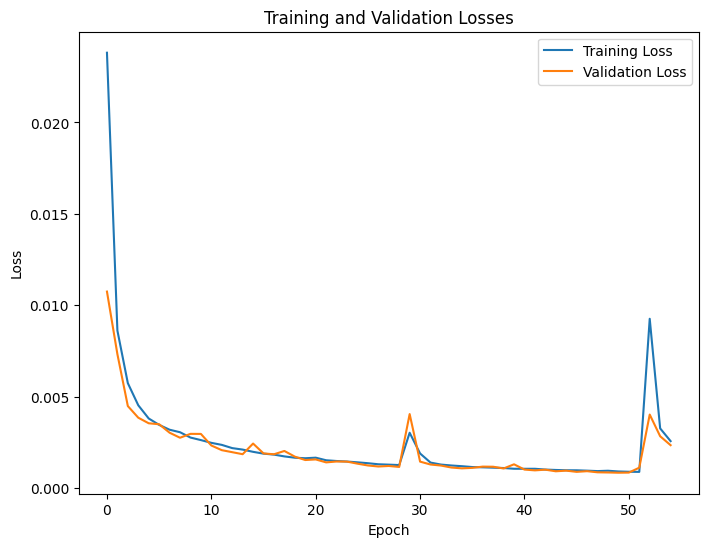

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


313/313 [==============================] - 1s 2ms/step
Metrics for Test Dataset:
Test MSE: 0.0024
Test MAE: 0.0345
Test PSNR: 26.23
Test SSIM: 0.98


In [57]:
from tensorflow.keras.datasets import cifar100
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Reshape, Conv2D, MaxPooling2D, UpSampling2D, Conv2DTranspose
from tensorflow.keras.optimizers import Adam
import numpy as np
import matplotlib.pyplot as plt
import cv2
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.callbacks import EarlyStopping

# Load the CIFAR100 dataset
(x_train, _), (x_test, _) = cifar100.load_data()

# Preprocess data
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
val_size = 0.2
val_index = int(len(x_train) * (1 - val_size))
x_val = x_train[val_index:]
x_train = x_train[:val_index]

# Define the VGG16 encoder
input_img = Input(shape=(32, 32, 3))
x = Conv2D(64, (3, 3), activation='relu', padding='same')(input_img)
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2), strides=(2, 2))(x)
x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2), strides=(2, 2))(x)
x = Conv2D(256, (3, 3), activation='relu', padding='same')(x)
x = Conv2D(256, (3, 3), activation='relu', padding='same')(x)
x = Conv2D(256, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), strides=(2, 2))(x)

# Create the encoder model
encoder = Model(inputs=input_img, outputs=encoded)

# Define the input shape for the decoder
input_shape = encoder.output_shape[1:]

# Define the decoder layers
decoder_input = Input(shape=input_shape)
x = Conv2DTranspose(128, (3, 3), strides=(2, 2), padding='same', activation='relu')(decoder_input)
x = Conv2DTranspose(64, (3, 3), strides=(2, 2), padding='same', activation='relu')(x)
x = Conv2DTranspose(3, (3, 3), strides=(2, 2), padding='same', activation='sigmoid')(x)

# Create the decoder model
decoder = Model(inputs=decoder_input, outputs=x)

# Connect the encoder and decoder
inputs = Input(shape=(32, 32, 3))
encoded = encoder(inputs)
decoded = decoder(encoded)

# Create the autoencoder model
autoencoder = Model(inputs=inputs, outputs=decoded)

# Compile the autoencoder model
autoencoder.compile(optimizer=Adam(), loss='mse')

# Define early stopping callback
early_stop = EarlyStopping(monitor='val_loss', patience=5)

# Train the autoencoder and record training history
history = autoencoder.fit(x_train, x_train, epochs=100, batch_size=128, shuffle=True,
                          validation_data=(x_val, x_val), callbacks=[early_stop])

# Plot training and validation losses
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Losses')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Save the model
autoencoder.save('/content/drive/MyDrive/Colab Notebooks/DLSIP_project/vgg16_model.h5')

# Encode and reconstruct the test images
test_encoded = encoder.predict(x_test)
test_reconstructed = decoder.predict(test_encoded)

test_mse = mean_squared_error(x_test.reshape(x_test.shape[0], -1), test_reconstructed.reshape(test_reconstructed.shape[0], -1))
test_mae = np.mean(np.abs(x_test.reshape(x_test.shape[0], -1) - test_reconstructed.reshape(test_reconstructed.shape[0], -1)))
test_psnr = peak_signal_noise_ratio(x_test, test_reconstructed, data_range=1.0)
test_ssim = structural_similarity(x_test, test_reconstructed, channel_axis=-1, data_range=1.0)

print("Metrics for Test Dataset:")
print(f"Test MSE: {test_mse:.4f}")
print(f"Test MAE: {test_mae:.4f}")
print(f"Test PSNR: {test_psnr:.2f}")
print(f"Test SSIM: {test_ssim:.2f}")

## **Sender**

In [58]:
# Load and preprocess the input image
image_path = '/content/drive/MyDrive/Colab Notebooks/DLSIP_project/Screenshot 2023-07-31 095636.jpg'
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
original_image = image.copy()
img = cv2.resize(image, (32, 32))
img = np.expand_dims(img, axis=0) / 255.0

# Load the saved model
loaded_model = load_model('/content/drive/MyDrive/Colab Notebooks/DLSIP_project/vgg16_model.h5')

# Extract the semantic features
semantic_features = encoder.predict(img)

print(semantic_features)
print(semantic_features.size)

1/1 [==============================] - 0s 355ms/step
[[[[0.         0.2870033  0.53697306 ... 0.         2.3256896
    3.1724317 ]
   [0.         0.38057843 0.33045816 ... 0.         2.3549926
    3.1336465 ]
   [0.         0.4632047  0.525852   ... 0.         1.9746461
    2.9753726 ]
   [0.         0.5405769  0.48945525 ... 0.         2.022227
    3.2502317 ]]

  [[0.         0.         0.6554356  ... 0.         1.0707033
    2.5947394 ]
   [0.         0.         0.91284317 ... 0.         0.22652969
    0.9617142 ]
   [0.         0.         1.0582638  ... 0.         1.4903256
    3.5671356 ]
   [0.         0.         0.8209335  ... 0.         1.6123276
    2.7139113 ]]

  [[0.         0.         0.6608612  ... 0.         1.9152547
    3.424082  ]
   [0.         0.         1.4850966  ... 0.         0.68168104
    3.4210231 ]
   [0.         0.         2.417908   ... 0.         0.45501694
    3.7663162 ]
   [0.         0.         0.7381261  ... 0.         2.1451674
    2.9684258 ]]

  [

## **Reciever**

1/1 [==============================] - 0s 74ms/step

Metrics for Input Image: (between resized and reconstructed image)
Input MSE: 0.0065
Input MAE: 0.0486
Input PSNR: 21.84
Input SSIM: 0.70


<ipython-input-59-7cd761bd2c6c>:27: FutureWarning: `multichannel` is a deprecated argument name for `structural_similarity`. It will be removed in version 1.0. Please use `channel_axis` instead.
  input_ssim = structural_similarity(original_image, resized_reconstructed_image, multichannel=True, data_range=255)



Metrics for Input Image (between original image and resized reconstructed image):
Input MSE: 60.9709
Input MAE: 121.5309
Input PSNR: 20.61
Input SSIM: 0.8232


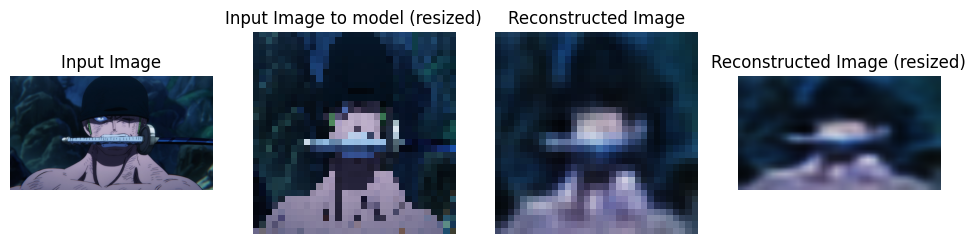

In [59]:
# Reconstruct the image using the semantic features
reconstructed_image = decoder.predict(semantic_features)

# Compute metrics for input image
reconstructed_image_flat = np.squeeze(reconstructed_image).reshape(-1, 3)
img_flat = img.reshape(-1, 3)

input_mse = mean_squared_error(img_flat, reconstructed_image_flat)
input_mae = np.mean(np.abs(img_flat - reconstructed_image_flat))
input_psnr = peak_signal_noise_ratio(img_flat, reconstructed_image_flat, data_range=1.0)
input_ssim = structural_similarity(img_flat, reconstructed_image_flat, channel_axis=-1, data_range=1.0)

print("\nMetrics for Input Image: (between resized and reconstructed image)")
print(f"Input MSE: {input_mse:.4f}")
print(f"Input MAE: {input_mae:.4f}")
print(f"Input PSNR: {input_psnr:.2f}")
print(f"Input SSIM: {input_ssim:.2f}")

# Resize the reconstructed image back to the original size
resized_reconstructed_image = cv2.resize(np.squeeze(reconstructed_image) * 255, (original_image.shape[1], original_image.shape[0]))
resized_reconstructed_image = resized_reconstructed_image.astype('uint8')

# Compute metrics for input image compared to original image
input_mse = mean_squared_error(original_image.reshape(-1, 3), resized_reconstructed_image.reshape(-1, 3))
input_mae = np.mean(np.abs(original_image.reshape(-1, 3) - resized_reconstructed_image.reshape(-1, 3)))
input_psnr = peak_signal_noise_ratio(original_image, resized_reconstructed_image, data_range=255)
input_ssim = structural_similarity(original_image, resized_reconstructed_image, multichannel=True, data_range=255)

print("\nMetrics for Input Image (between original image and resized reconstructed image):")
print(f"Input MSE: {input_mse:.4f}")
print(f"Input MAE: {input_mae:.4f}")
print(f"Input PSNR: {input_psnr:.2f}")
print(f"Input SSIM: {input_ssim:.4f}")

# Save the original image
cv2.imwrite('/content/drive/MyDrive/Colab Notebooks/DLSIP_project/SRGAN/original_image1_VGG16.png', cv2.cvtColor(original_image, cv2.COLOR_RGB2BGR))

# Save the resized reconstructed image
cv2.imwrite('/content/drive/MyDrive/Colab Notebooks/DLSIP_project/SRGAN/resized_reconstructed_image1_VGG16.png', cv2.cvtColor(resized_reconstructed_image, cv2.COLOR_RGB2BGR))

# Plot the input image, resized input image, and reconstructed image
plt.figure(figsize=(12, 4))
plt.subplot(1, 4, 1)
plt.imshow(original_image)
plt.axis('off')
plt.title('Input Image')

plt.subplot(1, 4, 2)
plt.imshow(img[0])
plt.axis('off')
plt.title('Input Image to model (resized)')

plt.subplot(1, 4, 3)
plt.imshow(np.squeeze(reconstructed_image))
plt.axis('off')
plt.title('Reconstructed Image')

plt.subplot(1, 4, 4)
plt.imshow(resized_reconstructed_image)
plt.axis('off')
plt.title('Reconstructed Image (resized)')

plt.show()

# **Sender**

In [60]:
# Load and preprocess the input image
image_path = '/content/drive/MyDrive/Colab Notebooks/DLSIP_project/Screenshot 2023-08-14 180929.png'
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
original_image = image.copy()
img = cv2.resize(image, (32, 32))
img = np.expand_dims(img, axis=0) / 255.0

# Load the saved model
loaded_model = load_model('/content/drive/MyDrive/Colab Notebooks/DLSIP_project/vgg16_model.h5')

# Extract the semantic features
semantic_features = encoder.predict(img)

print(semantic_features)
print(semantic_features.size)

1/1 [==============================] - 0s 17ms/step
[[[[0.         0.         0.58400434 ... 0.         2.615037
    2.0964696 ]
   [0.         0.         3.053926   ... 0.         1.7544767
    1.4868199 ]
   [0.         0.         0.975146   ... 0.         1.9266943
    2.2609735 ]
   [0.         0.         0.4674773  ... 0.         1.3652407
    2.6747208 ]]

  [[0.         0.         0.21107456 ... 0.         2.8357213
    1.499913  ]
   [0.         0.         0.68779975 ... 0.         1.286787
    1.8556808 ]
   [0.         0.         1.6369076  ... 0.         1.3793837
    2.2961423 ]
   [0.         0.         0.6101166  ... 0.         1.9655404
    2.178357  ]]

  [[0.         0.         0.21170643 ... 0.         1.5559233
    3.6572545 ]
   [0.         0.         0.94000286 ... 0.         2.668516
    3.1708558 ]
   [0.         0.         0.3667237  ... 0.         2.305115
    2.5700696 ]
   [0.         0.         0.36552766 ... 0.         2.3202155
    2.943528  ]]

  [[0.    

# **Reciever**

1/1 [==============================] - 0s 17ms/step

Metrics for Input Image: (between resized and reconstructed image)
Input MSE: 0.0051
Input MAE: 0.0495
Input PSNR: 22.89
Input SSIM: 0.77


<ipython-input-61-ed10afcdf225>:27: FutureWarning: `multichannel` is a deprecated argument name for `structural_similarity`. It will be removed in version 1.0. Please use `channel_axis` instead.
  input_ssim = structural_similarity(original_image, resized_reconstructed_image, multichannel=True, data_range=255)



Metrics for Input Image (between original image and resized reconstructed image):
Input MSE: 72.2744
Input MAE: 113.1800
Input PSNR: 21.35
Input SSIM: 0.6706


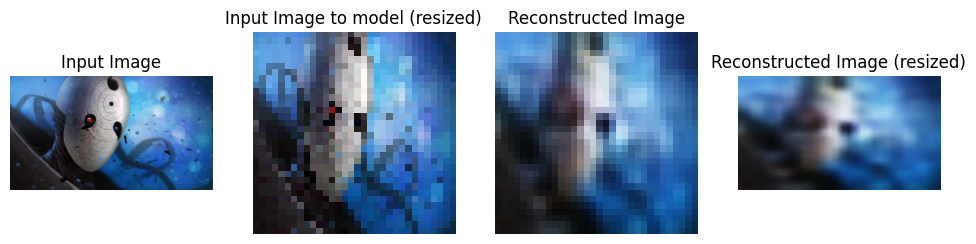

In [61]:
# Reconstruct the image using the semantic features
reconstructed_image = decoder.predict(semantic_features)

# Compute metrics for input image
reconstructed_image_flat = np.squeeze(reconstructed_image).reshape(-1, 3)
img_flat = img.reshape(-1, 3)

input_mse = mean_squared_error(img_flat, reconstructed_image_flat)
input_mae = np.mean(np.abs(img_flat - reconstructed_image_flat))
input_psnr = peak_signal_noise_ratio(img_flat, reconstructed_image_flat, data_range=1.0)
input_ssim = structural_similarity(img_flat, reconstructed_image_flat, channel_axis=-1, data_range=1.0)

print("\nMetrics for Input Image: (between resized and reconstructed image)")
print(f"Input MSE: {input_mse:.4f}")
print(f"Input MAE: {input_mae:.4f}")
print(f"Input PSNR: {input_psnr:.2f}")
print(f"Input SSIM: {input_ssim:.2f}")

# Resize the reconstructed image back to the original size
resized_reconstructed_image = cv2.resize(np.squeeze(reconstructed_image) * 255, (original_image.shape[1], original_image.shape[0]))
resized_reconstructed_image = resized_reconstructed_image.astype('uint8')

# Compute metrics for input image compared to original image
input_mse = mean_squared_error(original_image.reshape(-1, 3), resized_reconstructed_image.reshape(-1, 3))
input_mae = np.mean(np.abs(original_image.reshape(-1, 3) - resized_reconstructed_image.reshape(-1, 3)))
input_psnr = peak_signal_noise_ratio(original_image, resized_reconstructed_image, data_range=255)
input_ssim = structural_similarity(original_image, resized_reconstructed_image, multichannel=True, data_range=255)

print("\nMetrics for Input Image (between original image and resized reconstructed image):")
print(f"Input MSE: {input_mse:.4f}")
print(f"Input MAE: {input_mae:.4f}")
print(f"Input PSNR: {input_psnr:.2f}")
print(f"Input SSIM: {input_ssim:.4f}")

# Save the original image
cv2.imwrite('/content/drive/MyDrive/Colab Notebooks/DLSIP_project/SRGAN/original_image2_VGG16.png', cv2.cvtColor(original_image, cv2.COLOR_RGB2BGR))

# Save the resized reconstructed image
cv2.imwrite('/content/drive/MyDrive/Colab Notebooks/DLSIP_project/SRGAN/resized_reconstructed_image2_VGG16.png', cv2.cvtColor(resized_reconstructed_image, cv2.COLOR_RGB2BGR))

# Plot the input image, resized input image, and reconstructed image
plt.figure(figsize=(12, 4))
plt.subplot(1, 4, 1)
plt.imshow(original_image)
plt.axis('off')
plt.title('Input Image')

plt.subplot(1, 4, 2)
plt.imshow(img[0])
plt.axis('off')
plt.title('Input Image to model (resized)')

plt.subplot(1, 4, 3)
plt.imshow(np.squeeze(reconstructed_image))
plt.axis('off')
plt.title('Reconstructed Image')

plt.subplot(1, 4, 4)
plt.imshow(resized_reconstructed_image)
plt.axis('off')
plt.title('Reconstructed Image (resized)')

plt.show()

# **Sender**

In [62]:
# Load and preprocess the input image
image_path = '/content/drive/MyDrive/Colab Notebooks/DLSIP_project/Screenshot 2023-12-12 201012.png'
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
original_image = image.copy()
img = cv2.resize(image, (32, 32))
img = np.expand_dims(img, axis=0) / 255.0

# Load the saved model
loaded_model = load_model('/content/drive/MyDrive/Colab Notebooks/DLSIP_project/vgg16_model.h5')

# Extract the semantic features
semantic_features = encoder.predict(img)

print(semantic_features)
print(semantic_features.size)

1/1 [==============================] - 0s 17ms/step
[[[[0.         0.         0.51702946 ... 0.         0.504938
    3.515765  ]
   [0.         0.         0.83027047 ... 0.         0.06455478
    2.4709446 ]
   [0.         0.         0.6423848  ... 0.         0.
    3.3076763 ]
   [0.         0.         1.5346348  ... 0.         1.4800947
    4.0720997 ]]

  [[0.         0.         2.3454053  ... 0.         2.2041028
    4.841497  ]
   [0.         0.         0.7934928  ... 0.         0.3942426
    2.9813685 ]
   [0.         0.         1.0017216  ... 0.         0.9086782
    3.8131897 ]
   [0.         0.         1.861381   ... 0.         3.2307193
    3.0126107 ]]

  [[0.         0.         3.837122   ... 0.         1.8280268
    3.5702024 ]
   [0.         0.         5.086609   ... 0.         3.2916744
    3.151493  ]
   [0.         0.         2.5864098  ... 0.         1.1729299
    1.0936563 ]
   [0.         0.         4.0588903  ... 0.         1.7204229
    3.7439806 ]]

  [[1.340036 

# **Reciever**

1/1 [==============================] - 0s 16ms/step

Metrics for Input Image: (between resized and reconstructed image)
Input MSE: 0.0076
Input MAE: 0.0559
Input PSNR: 21.17
Input SSIM: 0.78


<ipython-input-63-a696883a9592>:27: FutureWarning: `multichannel` is a deprecated argument name for `structural_similarity`. It will be removed in version 1.0. Please use `channel_axis` instead.
  input_ssim = structural_similarity(original_image, resized_reconstructed_image, multichannel=True, data_range=255)



Metrics for Input Image (between original image and resized reconstructed image):
Input MSE: 69.8200
Input MAE: 134.6165
Input PSNR: 19.50
Input SSIM: 0.7890


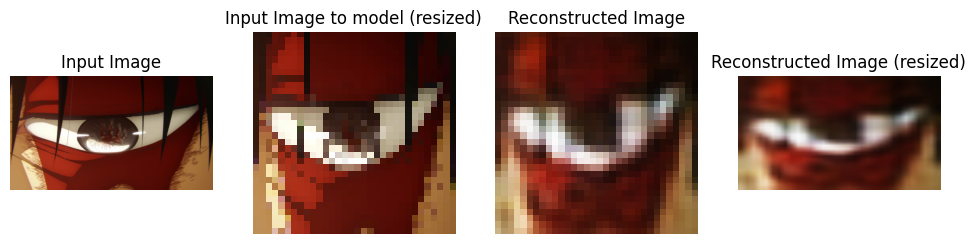

In [63]:
# Reconstruct the image using the semantic features
reconstructed_image = decoder.predict(semantic_features)

# Compute metrics for input image
reconstructed_image_flat = np.squeeze(reconstructed_image).reshape(-1, 3)
img_flat = img.reshape(-1, 3)

input_mse = mean_squared_error(img_flat, reconstructed_image_flat)
input_mae = np.mean(np.abs(img_flat - reconstructed_image_flat))
input_psnr = peak_signal_noise_ratio(img_flat, reconstructed_image_flat, data_range=1.0)
input_ssim = structural_similarity(img_flat, reconstructed_image_flat, channel_axis=-1, data_range=1.0)

print("\nMetrics for Input Image: (between resized and reconstructed image)")
print(f"Input MSE: {input_mse:.4f}")
print(f"Input MAE: {input_mae:.4f}")
print(f"Input PSNR: {input_psnr:.2f}")
print(f"Input SSIM: {input_ssim:.2f}")

# Resize the reconstructed image back to the original size
resized_reconstructed_image = cv2.resize(np.squeeze(reconstructed_image) * 255, (original_image.shape[1], original_image.shape[0]))
resized_reconstructed_image = resized_reconstructed_image.astype('uint8')

# Compute metrics for input image compared to original image
input_mse = mean_squared_error(original_image.reshape(-1, 3), resized_reconstructed_image.reshape(-1, 3))
input_mae = np.mean(np.abs(original_image.reshape(-1, 3) - resized_reconstructed_image.reshape(-1, 3)))
input_psnr = peak_signal_noise_ratio(original_image, resized_reconstructed_image, data_range=255)
input_ssim = structural_similarity(original_image, resized_reconstructed_image, multichannel=True, data_range=255)

print("\nMetrics for Input Image (between original image and resized reconstructed image):")
print(f"Input MSE: {input_mse:.4f}")
print(f"Input MAE: {input_mae:.4f}")
print(f"Input PSNR: {input_psnr:.2f}")
print(f"Input SSIM: {input_ssim:.4f}")

# Save the original image
cv2.imwrite('/content/drive/MyDrive/Colab Notebooks/DLSIP_project/SRGAN/original_image3_VGG16.png', cv2.cvtColor(original_image, cv2.COLOR_RGB2BGR))

# Save the resized reconstructed image
cv2.imwrite('/content/drive/MyDrive/Colab Notebooks/DLSIP_project/SRGAN/resized_reconstructed_image3_VGG16.png', cv2.cvtColor(resized_reconstructed_image, cv2.COLOR_RGB2BGR))

# Plot the input image, resized input image, and reconstructed image
plt.figure(figsize=(12, 4))
plt.subplot(1, 4, 1)
plt.imshow(original_image)
plt.axis('off')
plt.title('Input Image')

plt.subplot(1, 4, 2)
plt.imshow(img[0])
plt.axis('off')
plt.title('Input Image to model (resized)')

plt.subplot(1, 4, 3)
plt.imshow(np.squeeze(reconstructed_image))
plt.axis('off')
plt.title('Reconstructed Image')

plt.subplot(1, 4, 4)
plt.imshow(resized_reconstructed_image)
plt.axis('off')
plt.title('Reconstructed Image (resized)')

plt.show()

# **Skip Connections**

Epoch 1/100
313/313 [==============================] - 34s 68ms/step - loss: 0.0103 - val_loss: 0.0061
Epoch 2/100
313/313 [==============================] - 18s 57ms/step - loss: 0.0040 - val_loss: 0.0044
Epoch 3/100
313/313 [==============================] - 17s 56ms/step - loss: 0.0032 - val_loss: 0.0029
Epoch 4/100
313/313 [==============================] - 17s 55ms/step - loss: 0.0027 - val_loss: 0.0026
Epoch 5/100
313/313 [==============================] - 17s 55ms/step - loss: 0.0023 - val_loss: 0.0025
Epoch 6/100
313/313 [==============================] - 17s 56ms/step - loss: 0.0021 - val_loss: 0.0026
Epoch 7/100
313/313 [==============================] - 18s 56ms/step - loss: 0.0017 - val_loss: 0.0015
Epoch 8/100
313/313 [==============================] - 17s 56ms/step - loss: 0.0017 - val_loss: 0.0014
Epoch 9/100
313/313 [==============================] - 19s 60ms/step - loss: 0.0016 - val_loss: 0.0017
Epoch 10/100
313/313 [==============================] - 17s 56ms/step - l

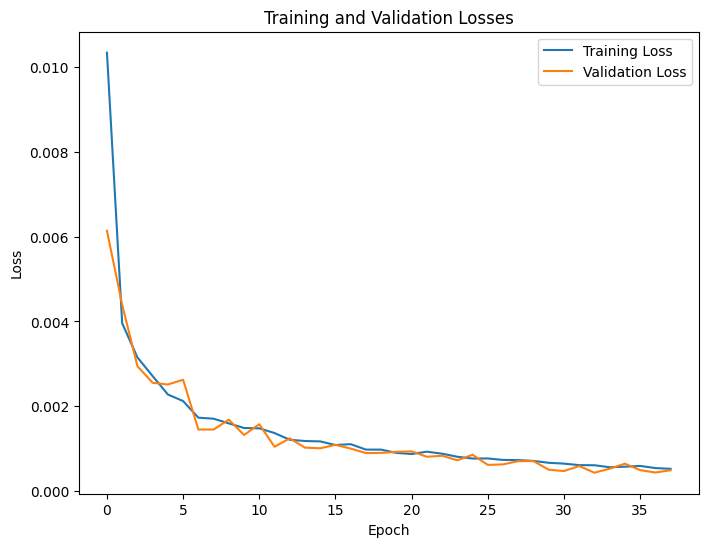

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


313/313 [==============================] - 1s 2ms/step
Metrics for Test Dataset:
Test MSE: 0.0005
Test MAE: 0.0160
Test PSNR: 33.04
Test SSIM: 1.00


In [1]:
from tensorflow.keras.datasets import cifar100
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Reshape, Conv2D, MaxPooling2D, UpSampling2D, Conv2DTranspose, BatchNormalization, Activation, Add
from tensorflow.keras.optimizers import Adam
import numpy as np
import matplotlib.pyplot as plt
import cv2
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.callbacks import EarlyStopping

# Load the CIFAR100 dataset
(x_train, _), (x_test, _) = cifar100.load_data()

# Preprocess data
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
val_size = 0.2
val_index = int(len(x_train) * (1 - val_size))
x_val = x_train[val_index:]
x_train = x_train[:val_index]

# Define the ResNet50 encoder
input_img = Input(shape=(32, 32, 3))

# First ResNet block
x = Conv2D(64, (3, 3), padding='same', kernel_initializer='he_normal')(input_img)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Conv2D(64, (3, 3), padding='same', kernel_initializer='he_normal')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
shortcut = x
x = Conv2D(64, (3, 3), strides=(2, 2), padding='same', kernel_initializer='he_normal')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
shortcut = Conv2D(64, (1, 1), strides=(2, 2), padding='same', kernel_initializer='he_normal')(shortcut)
x = Add()([x, shortcut])

# Second ResNet block
x = Conv2D(128, (3, 3), padding='same', kernel_initializer='he_normal')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Conv2D(128, (3, 3), padding='same', kernel_initializer='he_normal')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
shortcut = x
x = Conv2D(128, (3, 3), strides=(2, 2), padding='same', kernel_initializer='he_normal')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
shortcut = Conv2D(128, (1, 1), strides=(2, 2), padding='same', kernel_initializer='he_normal')(shortcut)
x = Add()([x, shortcut])

# Third ResNet block
x = Conv2D(256, (3, 3), padding='same', kernel_initializer='he_normal')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Conv2D(256, (3, 3), padding='same', kernel_initializer='he_normal')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
shortcut = x
x = Conv2D(256, (3, 3), strides=(2, 2), padding='same', kernel_initializer='he_normal')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
shortcut = Conv2D(256, (1, 1), strides=(2, 2), padding='same', kernel_initializer='he_normal')(shortcut)
x = Add()([x, shortcut])

encoded = x

# Create the encoder model
encoder = Model(inputs=input_img, outputs=encoded)

# Define the input shape for the decoder
input_shape = (4, 4, 256)  # Adjust this based on the encoder output shape

# Define the decoder layers
decoder_input = Input(shape=input_shape)
x = Conv2DTranspose(128, (3, 3), strides=(2, 2), padding='same', activation='relu')(decoder_input)
x = Conv2DTranspose(64, (3, 3), strides=(2, 2), padding='same', activation='relu')(x)
x = Conv2DTranspose(3, (3, 3), strides=(2, 2), padding='same', activation='sigmoid')(x)

# Create the decoder model
decoder = Model(inputs=decoder_input, outputs=x)

# Connect the encoder and decoder
inputs = Input(shape=(32, 32, 3))
encoded = encoder(inputs)
decoded = decoder(encoded)

# Create the autoencoder model
autoencoder = Model(inputs=inputs, outputs=decoded)

# Compile the autoencoder model
autoencoder.compile(optimizer=Adam(), loss='mse')

# Define early stopping callback
early_stop = EarlyStopping(monitor='val_loss', patience=5)

# Train the autoencoder and record training history
history = autoencoder.fit(x_train, x_train, epochs=100, batch_size=128, shuffle=True,
                          validation_data=(x_val, x_val), callbacks=[early_stop])

# Plot training and validation losses
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Losses')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Save the model
autoencoder.save('/content/drive/MyDrive/Colab Notebooks/DLSIP_project/resnet50_model.h5')

# Encode and reconstruct the test images
test_encoded = encoder.predict(x_test)
test_reconstructed = decoder.predict(test_encoded)

test_mse = mean_squared_error(x_test.reshape(x_test.shape[0], -1), test_reconstructed.reshape(test_reconstructed.shape[0], -1))
test_mae = np.mean(np.abs(x_test.reshape(x_test.shape[0], -1) - test_reconstructed.reshape(test_reconstructed.shape[0], -1)))
test_psnr = peak_signal_noise_ratio(x_test, test_reconstructed, data_range=1.0)
test_ssim = structural_similarity(x_test, test_reconstructed, channel_axis=-1, data_range=1.0)

print("Metrics for Test Dataset:")
print(f"Test MSE: {test_mse:.4f}")
print(f"Test MAE: {test_mae:.4f}")
print(f"Test PSNR: {test_psnr:.2f}")
print(f"Test SSIM: {test_ssim:.2f}")

## **Sender**

In [5]:
from tensorflow.keras.models import Sequential, load_model

# Load and preprocess the input image
image_path = '/content/drive/MyDrive/Colab Notebooks/DLSIP_project/Screenshot 2023-07-31 095636.jpg'
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
original_image = image.copy()
img = cv2.resize(image, (32, 32))
img = np.expand_dims(img, axis=0) / 255.0

# Load the saved model
loaded_model = load_model('/content/drive/MyDrive/Colab Notebooks/DLSIP_project/resnet50_model.h5')

# Extract the semantic features
semantic_features = encoder.predict(img)

print(semantic_features)
print(semantic_features.size)

1/1 [==============================] - 1s 502ms/step
[[[[ 0.39095485 -0.22960807 -0.13149686 ...  0.97750866 -0.1398921
     1.1747031 ]
   [-0.65781546 -0.35080487 -0.5610384  ...  0.01980692  0.7949699
     0.56827945]
   [-0.3643839   0.1297409   0.3095174  ... -0.13761014 -0.83066785
    -0.51710016]
   [ 0.39749706 -0.5177989   0.2448667  ... -0.37646914  0.08385336
     0.6936133 ]]

  [[ 0.04233032 -0.12180431  0.49475434 ... -0.05402768  0.2884252
     0.27665642]
   [-0.32734287 -0.29987812  1.5749187  ... -0.96744806 -0.24023247
     0.76867795]
   [ 1.1672      0.06373869 -0.18742417 ...  1.2118361  -1.7642388
    -0.0588034 ]
   [ 0.4388916   0.15339158  0.73249745 ... -0.5651121   0.11567497
    -0.03608687]]

  [[-0.11663359  0.2633653   0.6238842  ...  0.00301439 -0.36129677
     1.0062841 ]
   [-0.1665504   1.1452994   0.92760396 ...  0.5517206  -0.8158382
     1.6502191 ]
   [ 0.99643993  0.1499531  -0.85490453 ...  0.09815629 -0.14807305
     1.6459455 ]
   [ 1.937028

## **Reciever**

1/1 [==============================] - 0s 72ms/step

Metrics for Input Image: (between resized and reconstructed image)
Input MSE: 0.0016
Input MAE: 0.0266
Input PSNR: 28.09
Input SSIM: 0.87


<ipython-input-6-03c4112fa2df>:27: FutureWarning: `multichannel` is a deprecated argument name for `structural_similarity`. It will be removed in version 1.0. Please use `channel_axis` instead.
  input_ssim = structural_similarity(original_image, resized_reconstructed_image, multichannel=True, data_range=255)



Metrics for Input Image (between original image and resized reconstructed image):
Input MSE: 51.9316
Input MAE: 92.9238
Input PSNR: 21.75
Input SSIM: 0.8295


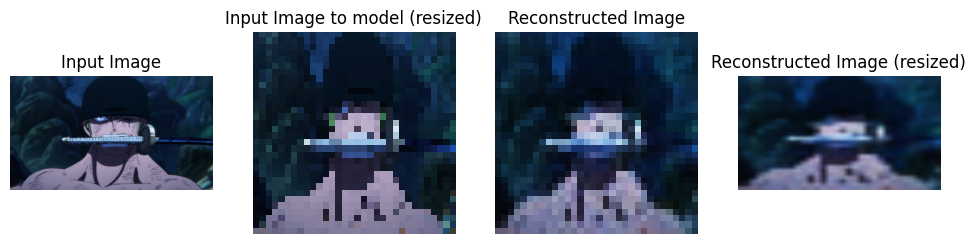

In [6]:
# Reconstruct the image using the semantic features
reconstructed_image = decoder.predict(semantic_features)

# Compute metrics for input image
reconstructed_image_flat = np.squeeze(reconstructed_image).reshape(-1, 3)
img_flat = img.reshape(-1, 3)

input_mse = mean_squared_error(img_flat, reconstructed_image_flat)
input_mae = np.mean(np.abs(img_flat - reconstructed_image_flat))
input_psnr = peak_signal_noise_ratio(img_flat, reconstructed_image_flat, data_range=1.0)
input_ssim = structural_similarity(img_flat, reconstructed_image_flat, channel_axis=-1, data_range=1.0)

print("\nMetrics for Input Image: (between resized and reconstructed image)")
print(f"Input MSE: {input_mse:.4f}")
print(f"Input MAE: {input_mae:.4f}")
print(f"Input PSNR: {input_psnr:.2f}")
print(f"Input SSIM: {input_ssim:.2f}")

# Resize the reconstructed image back to the original size
resized_reconstructed_image = cv2.resize(np.squeeze(reconstructed_image) * 255, (original_image.shape[1], original_image.shape[0]))
resized_reconstructed_image = resized_reconstructed_image.astype('uint8')

# Compute metrics for input image compared to original image
input_mse = mean_squared_error(original_image.reshape(-1, 3), resized_reconstructed_image.reshape(-1, 3))
input_mae = np.mean(np.abs(original_image.reshape(-1, 3) - resized_reconstructed_image.reshape(-1, 3)))
input_psnr = peak_signal_noise_ratio(original_image, resized_reconstructed_image, data_range=255)
input_ssim = structural_similarity(original_image, resized_reconstructed_image, multichannel=True, data_range=255)

print("\nMetrics for Input Image (between original image and resized reconstructed image):")
print(f"Input MSE: {input_mse:.4f}")
print(f"Input MAE: {input_mae:.4f}")
print(f"Input PSNR: {input_psnr:.2f}")
print(f"Input SSIM: {input_ssim:.4f}")

# Save the original image
cv2.imwrite('/content/drive/MyDrive/Colab Notebooks/DLSIP_project/SRGAN/original_image1_ResNet50.png', cv2.cvtColor(original_image, cv2.COLOR_RGB2BGR))

# Save the resized reconstructed image
cv2.imwrite('/content/drive/MyDrive/Colab Notebooks/DLSIP_project/SRGAN/resized_reconstructed_image1_ResNet50.png', cv2.cvtColor(resized_reconstructed_image, cv2.COLOR_RGB2BGR))

# Plot the input image, resized input image, and reconstructed image
plt.figure(figsize=(12, 4))
plt.subplot(1, 4, 1)
plt.imshow(original_image)
plt.axis('off')
plt.title('Input Image')

plt.subplot(1, 4, 2)
plt.imshow(img[0])
plt.axis('off')
plt.title('Input Image to model (resized)')

plt.subplot(1, 4, 3)
plt.imshow(np.squeeze(reconstructed_image))
plt.axis('off')
plt.title('Reconstructed Image')

plt.subplot(1, 4, 4)
plt.imshow(resized_reconstructed_image)
plt.axis('off')
plt.title('Reconstructed Image (resized)')

plt.show()

## **Sender**

In [7]:
# Load and preprocess the input image
image_path = '/content/drive/MyDrive/Colab Notebooks/DLSIP_project/Screenshot 2023-08-14 180929.png'
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
original_image = image.copy()
img = cv2.resize(image, (32, 32))
img = np.expand_dims(img, axis=0) / 255.0

# Load the saved model
loaded_model = load_model('/content/drive/MyDrive/Colab Notebooks/DLSIP_project/resnet50_model.h5')

# Extract the semantic features
semantic_features = encoder.predict(img)

print(semantic_features)
print(semantic_features.size)

1/1 [==============================] - 0s 33ms/step
[[[[ 9.4593853e-01  1.2545543e+00 -1.2474501e-01 ...  5.1688600e-01
     1.4688724e-01  3.7709135e-01]
   [-6.5804905e-01  1.1020924e+00  9.6242464e-01 ... -1.5079315e+00
    -1.6750731e-01 -1.5816706e-01]
   [-6.4444906e-01  1.6811379e+00 -7.3453754e-01 ...  1.5928741e-01
     1.3396809e+00  2.2712171e-02]
   [ 5.5906355e-01 -4.9421716e-01  1.7515752e-01 ... -1.4920148e-01
    -1.0848427e-01 -8.6102545e-02]]

  [[-1.5916369e+00  1.0045125e+00 -7.9677749e-01 ... -1.1137867e-01
    -4.7153610e-01 -7.6859601e-02]
   [-1.4133162e+00  1.5877037e+00 -4.9645800e-02 ...  3.1336480e-01
    -1.3572502e+00 -6.4062899e-01]
   [ 3.2207065e+00  3.0182226e+00 -4.0643823e-01 ... -5.9329450e-01
     9.7262311e-01  1.8155981e+00]
   [-3.0964553e-01  4.9262181e-01 -1.9564904e-01 ... -6.4525205e-01
     1.7487755e-01  3.4276909e-01]]

  [[-4.4386566e-01  1.0472123e-01  5.3625442e-02 ...  7.6730770e-01
    -1.4161597e+00  1.6482440e+00]
   [-5.4763073e-0

## **Reciever**

1/1 [==============================] - 0s 25ms/step

Metrics for Input Image: (between resized and reconstructed image)
Input MSE: 0.0021
Input MAE: 0.0336
Input PSNR: 26.76
Input SSIM: 0.91


<ipython-input-8-3b1eb7ef4e9b>:27: FutureWarning: `multichannel` is a deprecated argument name for `structural_similarity`. It will be removed in version 1.0. Please use `channel_axis` instead.
  input_ssim = structural_similarity(original_image, resized_reconstructed_image, multichannel=True, data_range=255)



Metrics for Input Image (between original image and resized reconstructed image):
Input MSE: 69.4059
Input MAE: 104.0392
Input PSNR: 22.23
Input SSIM: 0.6745


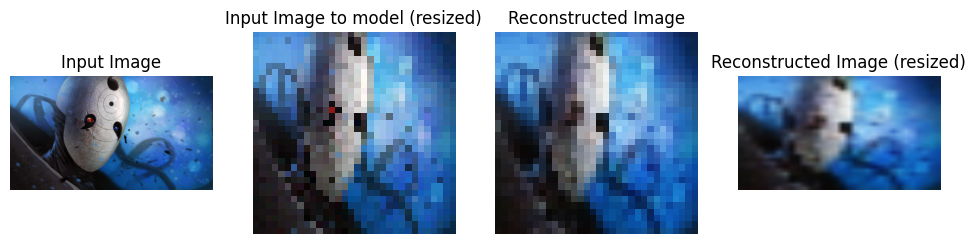

In [8]:
# Reconstruct the image using the semantic features
reconstructed_image = decoder.predict(semantic_features)

# Compute metrics for input image
reconstructed_image_flat = np.squeeze(reconstructed_image).reshape(-1, 3)
img_flat = img.reshape(-1, 3)

input_mse = mean_squared_error(img_flat, reconstructed_image_flat)
input_mae = np.mean(np.abs(img_flat - reconstructed_image_flat))
input_psnr = peak_signal_noise_ratio(img_flat, reconstructed_image_flat, data_range=1.0)
input_ssim = structural_similarity(img_flat, reconstructed_image_flat, channel_axis=-1, data_range=1.0)

print("\nMetrics for Input Image: (between resized and reconstructed image)")
print(f"Input MSE: {input_mse:.4f}")
print(f"Input MAE: {input_mae:.4f}")
print(f"Input PSNR: {input_psnr:.2f}")
print(f"Input SSIM: {input_ssim:.2f}")

# Resize the reconstructed image back to the original size
resized_reconstructed_image = cv2.resize(np.squeeze(reconstructed_image) * 255, (original_image.shape[1], original_image.shape[0]))
resized_reconstructed_image = resized_reconstructed_image.astype('uint8')

# Compute metrics for input image compared to original image
input_mse = mean_squared_error(original_image.reshape(-1, 3), resized_reconstructed_image.reshape(-1, 3))
input_mae = np.mean(np.abs(original_image.reshape(-1, 3) - resized_reconstructed_image.reshape(-1, 3)))
input_psnr = peak_signal_noise_ratio(original_image, resized_reconstructed_image, data_range=255)
input_ssim = structural_similarity(original_image, resized_reconstructed_image, multichannel=True, data_range=255)

print("\nMetrics for Input Image (between original image and resized reconstructed image):")
print(f"Input MSE: {input_mse:.4f}")
print(f"Input MAE: {input_mae:.4f}")
print(f"Input PSNR: {input_psnr:.2f}")
print(f"Input SSIM: {input_ssim:.4f}")

# Save the original image
cv2.imwrite('/content/drive/MyDrive/Colab Notebooks/DLSIP_project/SRGAN/original_image2_ResNet50.png', cv2.cvtColor(original_image, cv2.COLOR_RGB2BGR))

# Save the resized reconstructed image
cv2.imwrite('/content/drive/MyDrive/Colab Notebooks/DLSIP_project/SRGAN/resized_reconstructed_image2_ResNet50.png', cv2.cvtColor(resized_reconstructed_image, cv2.COLOR_RGB2BGR))

# Plot the input image, resized input image, and reconstructed image
plt.figure(figsize=(12, 4))
plt.subplot(1, 4, 1)
plt.imshow(original_image)
plt.axis('off')
plt.title('Input Image')

plt.subplot(1, 4, 2)
plt.imshow(img[0])
plt.axis('off')
plt.title('Input Image to model (resized)')

plt.subplot(1, 4, 3)
plt.imshow(np.squeeze(reconstructed_image))
plt.axis('off')
plt.title('Reconstructed Image')

plt.subplot(1, 4, 4)
plt.imshow(resized_reconstructed_image)
plt.axis('off')
plt.title('Reconstructed Image (resized)')

plt.show()

## **Sender**

In [9]:
# Load and preprocess the input image
image_path = '/content/drive/MyDrive/Colab Notebooks/DLSIP_project/Screenshot 2023-12-12 201012.png'
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
original_image = image.copy()
img = cv2.resize(image, (32, 32))
img = np.expand_dims(img, axis=0) / 255.0

# Load the saved model
loaded_model = load_model('/content/drive/MyDrive/Colab Notebooks/DLSIP_project/resnet50_model.h5')

# Extract the semantic features
semantic_features = encoder.predict(img)

print(semantic_features)
print(semantic_features.size)

1/1 [==============================] - 0s 18ms/step
[[[[ 2.1058989e-01  1.1983280e+00 -4.9793777e-01 ...  7.5592911e-01
    -7.2750783e-01  1.2080543e+00]
   [-2.9924047e-01  1.2107612e+00 -7.3399258e-01 ... -6.4537406e-02
     5.3472114e-01  1.7789458e+00]
   [ 8.3090514e-01  1.0733820e+00 -5.2383155e-01 ...  1.4671433e-01
     9.0150094e-01  5.1589280e-01]
   [ 5.2992713e-01  5.6218302e-01 -8.1240773e-02 ...  2.5239384e-01
    -7.3500824e-01  1.0580926e+00]]

  [[-8.2913697e-01  8.2358503e-01  1.7785876e+00 ... -1.8889315e-01
    -9.7881454e-01  3.2098618e+00]
   [-4.1806686e-01 -4.5750418e-01 -5.6271803e-01 ...  9.4870585e-01
    -2.4384046e-01 -1.4367731e+00]
   [ 2.6675993e-01  1.5310084e+00  2.9863493e+00 ... -1.0940266e+00
    -6.7652118e-01  8.3291396e-02]
   [-1.2329862e+00  1.5257090e+00 -1.9110554e+00 ... -9.8986089e-01
     9.0226638e-01  1.0466335e+00]]

  [[-1.0000143e+00 -4.0692702e-01 -1.0066599e+00 ...  1.9902442e+00
    -3.2577673e-01  1.3843229e+00]
   [ 2.5458593e+0

## **Reciever**

1/1 [==============================] - 0s 16ms/step

Metrics for Input Image: (between resized and reconstructed image)
Input MSE: 0.0016
Input MAE: 0.0273
Input PSNR: 27.84
Input SSIM: 0.91


<ipython-input-10-9dbfcd238e6b>:27: FutureWarning: `multichannel` is a deprecated argument name for `structural_similarity`. It will be removed in version 1.0. Please use `channel_axis` instead.
  input_ssim = structural_similarity(original_image, resized_reconstructed_image, multichannel=True, data_range=255)



Metrics for Input Image (between original image and resized reconstructed image):
Input MSE: 53.1718
Input MAE: 84.8704
Input PSNR: 20.91
Input SSIM: 0.8134


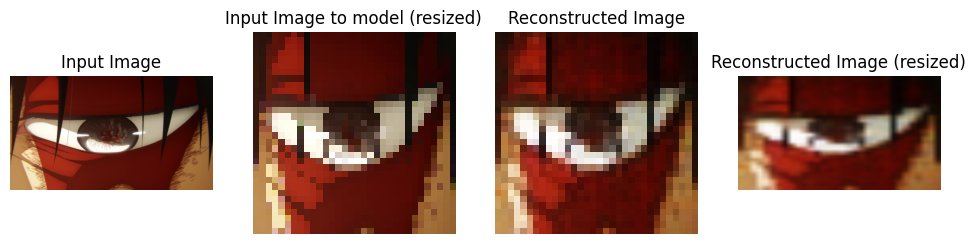

In [10]:
# Reconstruct the image using the semantic features
reconstructed_image = decoder.predict(semantic_features)

# Compute metrics for input image
reconstructed_image_flat = np.squeeze(reconstructed_image).reshape(-1, 3)
img_flat = img.reshape(-1, 3)

input_mse = mean_squared_error(img_flat, reconstructed_image_flat)
input_mae = np.mean(np.abs(img_flat - reconstructed_image_flat))
input_psnr = peak_signal_noise_ratio(img_flat, reconstructed_image_flat, data_range=1.0)
input_ssim = structural_similarity(img_flat, reconstructed_image_flat, channel_axis=-1, data_range=1.0)

print("\nMetrics for Input Image: (between resized and reconstructed image)")
print(f"Input MSE: {input_mse:.4f}")
print(f"Input MAE: {input_mae:.4f}")
print(f"Input PSNR: {input_psnr:.2f}")
print(f"Input SSIM: {input_ssim:.2f}")

# Resize the reconstructed image back to the original size
resized_reconstructed_image = cv2.resize(np.squeeze(reconstructed_image) * 255, (original_image.shape[1], original_image.shape[0]))
resized_reconstructed_image = resized_reconstructed_image.astype('uint8')

# Compute metrics for input image compared to original image
input_mse = mean_squared_error(original_image.reshape(-1, 3), resized_reconstructed_image.reshape(-1, 3))
input_mae = np.mean(np.abs(original_image.reshape(-1, 3) - resized_reconstructed_image.reshape(-1, 3)))
input_psnr = peak_signal_noise_ratio(original_image, resized_reconstructed_image, data_range=255)
input_ssim = structural_similarity(original_image, resized_reconstructed_image, multichannel=True, data_range=255)

print("\nMetrics for Input Image (between original image and resized reconstructed image):")
print(f"Input MSE: {input_mse:.4f}")
print(f"Input MAE: {input_mae:.4f}")
print(f"Input PSNR: {input_psnr:.2f}")
print(f"Input SSIM: {input_ssim:.4f}")

# Save the original image
cv2.imwrite('/content/drive/MyDrive/Colab Notebooks/DLSIP_project/SRGAN/original_image3_ResNet50.png', cv2.cvtColor(original_image, cv2.COLOR_RGB2BGR))

# Save the resized reconstructed image
cv2.imwrite('/content/drive/MyDrive/Colab Notebooks/DLSIP_project/SRGAN/resized_reconstructed_image3_ResNet50.png', cv2.cvtColor(resized_reconstructed_image, cv2.COLOR_RGB2BGR))

# Plot the input image, resized input image, and reconstructed image
plt.figure(figsize=(12, 4))
plt.subplot(1, 4, 1)
plt.imshow(original_image)
plt.axis('off')
plt.title('Input Image')

plt.subplot(1, 4, 2)
plt.imshow(img[0])
plt.axis('off')
plt.title('Input Image to model (resized)')

plt.subplot(1, 4, 3)
plt.imshow(np.squeeze(reconstructed_image))
plt.axis('off')
plt.title('Reconstructed Image')

plt.subplot(1, 4, 4)
plt.imshow(resized_reconstructed_image)
plt.axis('off')
plt.title('Reconstructed Image (resized)')

plt.show()